In [1]:
import typing as t

import polars as pl

from src.config.constants import Product
from src.research import (
    AnalysisResult,
    OrderbookAnalysisResult,
    Plots,
    TradesAnalysisResult,
    display_plots,
    run_analysis,
)

INTARIAN_PEPPER_ROOT: t.Final[Product] = Product.INTARIAN_PEPPER_ROOT
ROUND: t.Final[int] = 1
DAY: t.Final[int] = 0

analysis_result: t.Final[AnalysisResult] = run_analysis(
    ROUND, DAY, INTARIAN_PEPPER_ROOT
)
orderbook_analysis: t.Final[OrderbookAnalysisResult] = (
    analysis_result.orderbook_analysis_result
)
trades_analysis: t.Final[TradesAnalysisResult] = analysis_result.trades_analysis_result
plots: t.Final[Plots] = analysis_result.plots

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,i64
0,11991,19,null,null,null,null,12006,10,12009,19,null,null,11998.5,15,-0.208333,null,0.000167,12000.827586,2.327586,29
100,11994,9,11991,23,null,null,12007,9,12010,23,null,null,12000.5,13,0.0,0.000167,-0.000125,12000.5,0.0,18
200,11991,20,null,null,null,null,12007,11,12010,20,null,null,11999.0,16,-0.215686,-0.000125,0.000125,12001.322581,2.322581,31
300,11994,10,11991,24,null,null,12007,10,null,null,null,null,12000.5,13,0.545455,0.000125,-0.000542,12000.5,0.0,20
400,11994,12,11991,25,null,null,null,null,null,null,null,null,11994.0,null,1.0,-0.000542,0.000542,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,12989,19,null,null,null,null,13006,12,null,null,null,null,12997.5,17,0.225806,-0.000115,0.000192,12999.419355,1.919355,31
999600,12993,8,null,null,null,null,13007,8,13010,25,null,null,13000.0,14,-0.609756,0.000192,-0.000154,13000.0,0.0,16
999700,12989,20,null,null,null,null,13007,10,13010,20,null,null,12998.0,18,-0.2,-0.000154,0.000692,13001.0,3.0,30


In [3]:
orderbook_features_data

timestamp,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,i64,f64,f64,f64,f64,f64,i64
0,11998.5,15,-0.208333,null,0.000167,12000.827586,2.327586,29
100,12000.5,13,0.0,0.000167,-0.000125,12000.5,0.0,18
200,11999.0,16,-0.215686,-0.000125,0.000125,12001.322581,2.322581,31
300,12000.5,13,0.545455,0.000125,-0.000542,12000.5,0.0,20
400,11994.0,null,1.0,-0.000542,0.000542,null,null,null
…,…,…,…,…,…,…,…,…
999500,12997.5,17,0.225806,-0.000115,0.000192,12999.419355,1.919355,31
999600,13000.0,14,-0.609756,0.000192,-0.000154,13000.0,0.0,16
999700,12998.0,18,-0.2,-0.000154,0.000692,13001.0,3.0,30


In [4]:
orderbook_stats

mid_mean,mid_var,mid_std,micro_mean,micro_var,micro_std,ret_mean,ret_var,ret_std
f64,f64,f64,f64,f64,f64,f64,f64,f64
12500.173013,83365.582335,288.730986,12500.976842,83051.401652,288.186401,0.000008,7.0980e-8,0.000266


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
0.36972,0.317648


# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
quantities_stats: t.Final[pl.DataFrame] = trades_analysis.quantities_stats
order_side_stats: t.Final[pl.DataFrame] = trades_analysis.order_side_stats
trade_price_streaks_stats: t.Final[pl.DataFrame] = (
    trades_analysis.trade_price_streaks_stats
)

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
200,12007.0,5,11991,12007,11999.0,null,3100,8.0,"""BUY_ORDER"""
3300,12010.0,7,null,12010,12010.0,3100,800,0.0,"""UNKNOWN"""
4100,11998.0,6,11998,null,11998.0,800,2700,0.0,"""UNKNOWN"""
6800,12000.0,5,12000,12013,12006.5,2700,2500,-6.5,"""SELL_ORDER"""
9300,12005.0,6,12003,12005,12004.0,2500,2600,1.0,"""BUY_ORDER"""
…,…,…,…,…,…,…,…,…,…
990700,12998.0,6,12984,12998,12991.0,500,200,7.0,"""BUY_ORDER"""
990900,12984.0,6,12984,12998,12991.0,200,400,-7.0,"""SELL_ORDER"""
991300,12984.0,3,12984,12998,12991.0,400,3700,-7.0,"""SELL_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
3015.70997,8.9951e6,2999.180852,3015.70997,8.9951e6,2999.180852


In [8]:
quantities_stats

qty_mean,qty_median,qty_mode,qty_var,qty_std
f64,f64,i64,f64,f64
5.204819,5.0,5,2.405052,1.550823


In [9]:
order_side_stats

total_orders,buy_orders,buy_order_rate,sell_orders,sell_order_rate
i64,i64,f64,i64,f64
332,158,0.475904,163,0.490964


In [10]:
trade_price_streaks_stats

price,streak_length
f64,u32
12941.0,1
12984.0,2
12948.0,2
12296.0,1
12190.0,1
…,…
12144.0,1
12444.0,2
12856.0,1


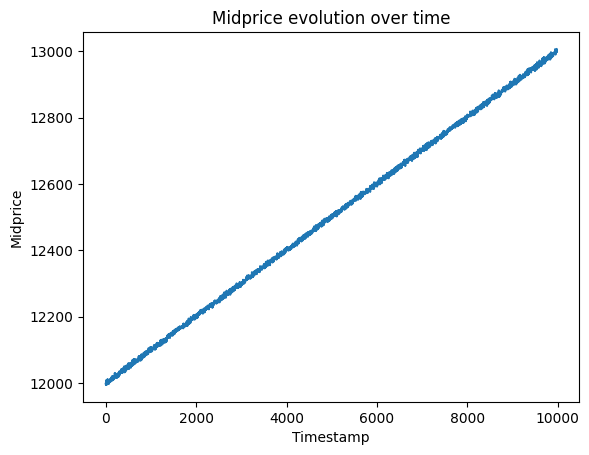

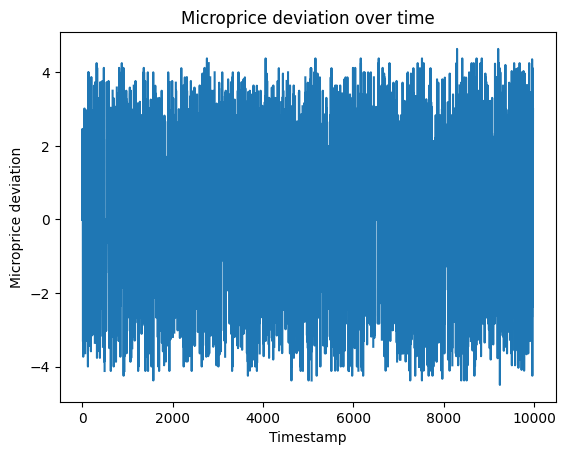

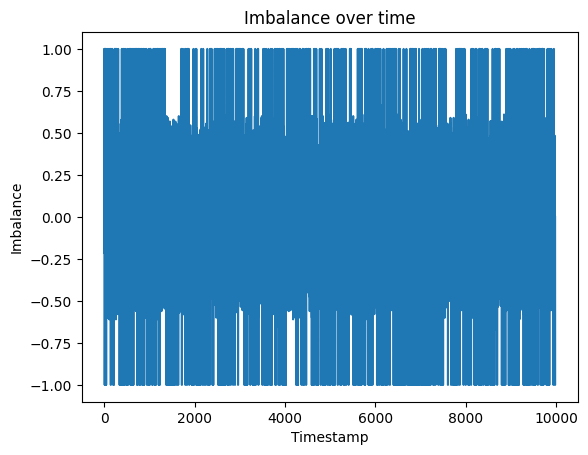

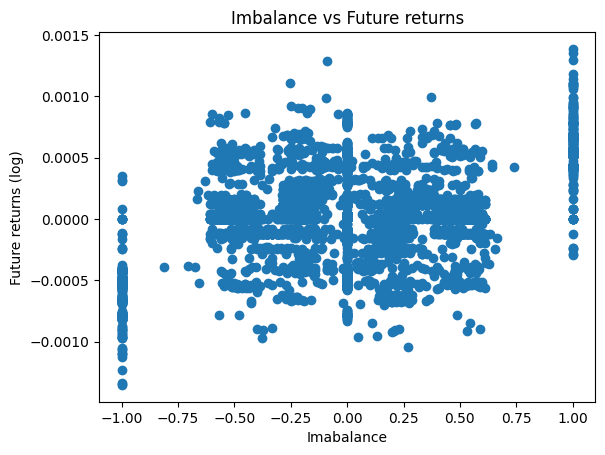

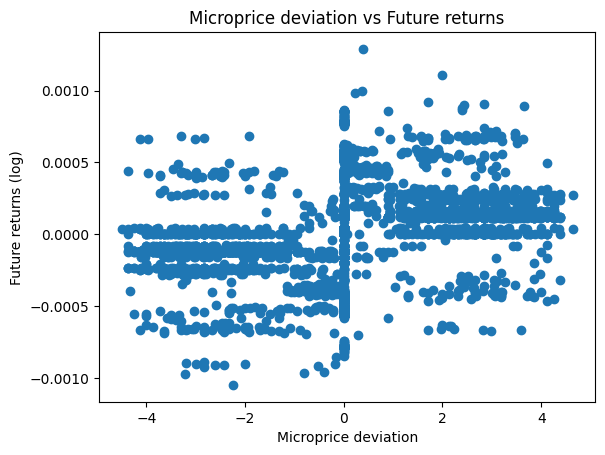

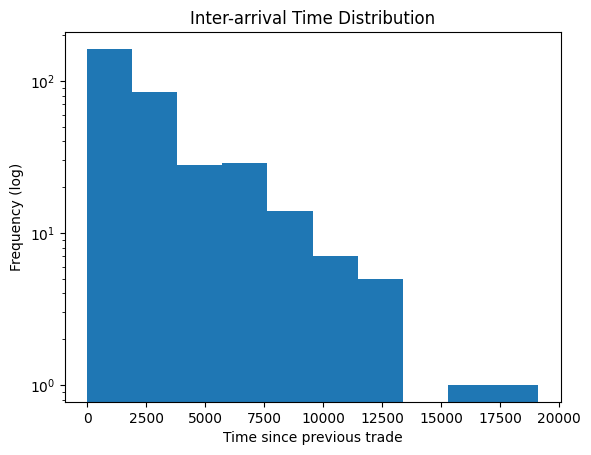

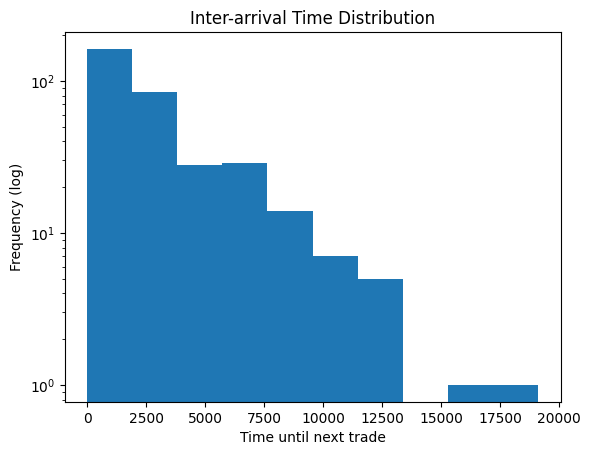

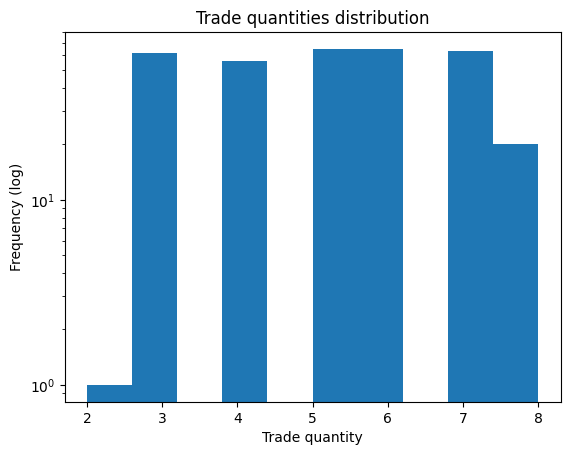

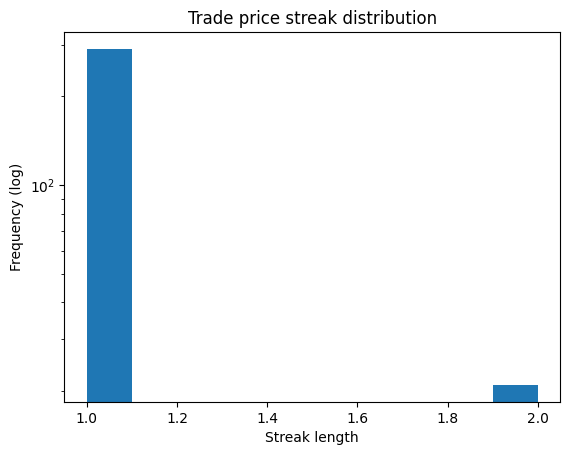

In [11]:
display_plots(plots)